<a href="https://colab.research.google.com/github/msemihyasa/Semih/blob/main/ML_Final_244329037.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

T.C. Üsküdar Üniversitesi

Yapay Zeka Mühendisliği Yüksek Lisans Programı

Makina Öğrenmesi Final Ödevi

Machine Learning Pipeline: Feature Selection and Hyperparameter Optimization

Dr. Öğr. Üyesi Gökalp TULUM

Hazırlayan: 244329037 Mehmet Semih YAŞA

Projenin Konusu:

Yüksek enerjili parçacık fiziğinde Higgs bozonunun varlığını tahmin etmek amacıyla hazırlanmış, büyük ölçekli ve etiketli bir sınıflandırma veri kümesi üzerinde supervised learning modelleri ile çalışarak makine öğrenmesi sürecinin iki önemli bileşeni olan özellik seçimi (feature selection) ve hiperparametre ayarlaması (hyperparameter tuning) adımlarının uygulanmasıdır.  

HIGGS data seti nedir?

Her satır, CERN'de yapılan tek bir parçacık çarpışma olayıdır.
Her gözlem ise dedektörlerde ölçülen fiziksel nicelikleri ve bu olayın Higgs bozonu içerip içermediğine dair etiketi temsil eder.

Projenin Amacı:

Bir çarpışma olayının Higgs bozonu sinyali mi yoksa arka plan (background) mı olduğunu tahmin etmek.

### 1. Veri Setinin Yüklenmesi

#### 1.1. Drive'dan Veri Seti Yükleme

In [1]:
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


#### Kütüphanelerin Yüklenmesi

In [2]:
!pip install optuna

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_selection import SelectKBest, mutual_info_classif, f_classif
from sklearn.preprocessing import MinMaxScaler

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.model_selection import StratifiedKFold, cross_val_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc

from sklearn.pipeline import Pipeline


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 21.9 MB/s eta 0:00:00


#### 1.2. Çalışma Verisinin Ayrılması (5k)

In [ ]:
# 5000'lik veriyi farklı kaydet

# Dosya adresi
input_path  = '/content/drive/MyDrive/HIGGS.csv'
output_path = '/content/drive/MyDrive/HIGGS_5000.csv'

# HIGGS'in header'ı yok, 29 sütun var. ilk sütun label.
col_names = ['label'] + [f'feature_{i}' for i in range(1, 29)]

df = pd.read_csv(
    input_path,
    nrows=5000,
    header=None,
    names=col_names
)

df.to_csv(output_path, index=False)

print(f"Shape : {df.shape}")
print(f"Label dağılımı:\n{df['label'].value_counts()}")
print(f"\nKaydedildi → {output_path}")

Shape : (5000, 29)
Label dağılımı:
label
1.0    2670
0.0    2330
Name: count, dtype: int64

Kaydedildi → /content/drive/MyDrive/HIGGS_5000.csv


Not: İlk önce 5.000 satırlık veri ile çalışılarak proje tamamladım. Daha sonra 100.000 satırlık veri ile çalıştım.

Jupyter Notebook'ta da Colab Pro'da da SVM için çalışmayı tamamlayamadım.

SVM'de Linear'ı kaldırarak sadece rbf ile denedim. İç döngüde Inner sample 20.000 satır ile limitledim. PC'de çalıştırdığımda 15 saat sonunda tek fold tamamlayamadı. Colab PRO'da 24 saat sonunda 4 fold tamamlandı fakat bağlantı kesildi.

Bu sebeple çalışmayı 10.000 satır veri ile revize ettim.


#### 1.3. Çalışma Verisinin Ayrılması (10k)

In [3]:
# 10.000'lik veriyi farklı kaydet

# Dosya adresi
input_path  = '/content/drive/MyDrive/HIGGS.csv'
output_path = '/content/drive/MyDrive/HIGGS_10k.csv'

col_names = ['label'] + [f'feature_{i}' for i in range(1, 29)]

df = pd.read_csv(
    input_path,
    nrows=10000,
    header=None,
    names=col_names
)

df.to_csv(output_path, index=False)

print(f"Shape : {df.shape}")
print(f"Label dağılımı:\n{df['label'].value_counts()}")
print(f"\nKaydedildi → {output_path}")

Shape : (10000, 29)
Label dağılımı:
label
1.0    5295
0.0    4705
Name: count, dtype: int64

Kaydedildi → /content/drive/MyDrive/HIGGS_10k.csv


#### 1.4. Çalışma Verisinin Yüklenmesi

In [4]:
# data_path = '/content/drive/MyDrive/HIGGS_5000.csv'
# data_path = '/content/drive/MyDrive/HIGGS_100k.csv'

data_path = '/content/drive/MyDrive/HIGGS_10k.csv'
df = pd.read_csv(data_path)

col_names = ['label'] + [f'feature_{i}' for i in range(1, 29)]

print(f"Çalışma verisi başarıyla yüklendi.")
print()
print(f"Boyut : {df.shape}")
print(f"Label dağılımı:\n{df['label'].value_counts()}")
df.head()

print(f"\nVeri Tipleri:\n{df.dtypes}")



Çalışma verisi başarıyla yüklendi.

Boyut : (10000, 29)
Label dağılımı:
label
1.0    5295
0.0    4705
Name: count, dtype: int64

Veri Tipleri:
label         float64
feature_1     float64
feature_2     float64
feature_3     float64
feature_4     float64
feature_5     float64
feature_6     float64
feature_7     float64
feature_8     float64
feature_9     float64
feature_10    float64
feature_11    float64
feature_12    float64
feature_13    float64
feature_14    float64
feature_15    float64
feature_16    float64
feature_17    float64
feature_18    float64
feature_19    float64
feature_20    float64
feature_21    float64
feature_22    float64
feature_23    float64
feature_24    float64
feature_25    float64
feature_26    float64
feature_27    float64
feature_28    float64
dtype: object


### 2. Eksik Değer Analizi

In [5]:
# eksik değer analizi
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Eksik Sayı': missing, 'Eksik %': missing_pct})
missing_df = missing_df[missing_df['Eksik Sayı'] > 0]

if missing_df.empty:
    print("\nEksik değer yok.")
else:
    print(f"\nEksik Değer Özeti:\n{missing_df}")

# istatistiksel özet
print("\nİstatistiksel Özet:")
display(df.describe().T.style.background_gradient(cmap='Blues'))


Eksik değer yok.

İstatistiksel Özet:


,count,mean,std,min,25%,50%,75%,max
label,10000.000000,0.529500,0.499154,0.000000,0.000000,1.000000,1.000000,1.000000
feature_1,10000.000000,0.997924,0.574965,0.275063,0.596061,0.858770,1.248305,6.695388
feature_2,10000.000000,-0.016681,1.002943,-2.425236,-0.744166,-0.028786,0.714839,2.429998
feature_3,10000.000000,-0.003486,1.010838,-1.742508,-0.872486,0.000643,0.881675,1.743236
feature_4,10000.000000,0.991385,0.595460,0.012355,0.571250,0.886284,1.294626,5.824007
feature_5,10000.000000,-0.009822,1.004828,-1.743755,-0.885740,-0.019940,0.856703,1.742818
feature_6,10000.000000,0.992058,0.477408,0.159488,0.679817,0.897522,1.170305,7.064657
feature_7,10000.000000,-0.001468,1.004115,-2.941008,-0.682789,-0.009928,0.680263,2.969674
feature_8,10000.000000,0.003751,1.015907,-1.741237,-0.892627,0.020396,0.878984,1.741454
feature_9,10000.000000,1.004939,1.026965,0.000000,0.000000,1.086538,2.173076,2.173076


### 3. Aykırı Değer (Outlier) Analizi

Özellik Başına Aykırı Değer:


,Aykırı Sayı,Aykırı %
feature_24,1958,19.58
feature_22,1379,13.79
feature_23,761,7.61
feature_26,646,6.46
feature_27,639,6.39
feature_28,606,6.06
feature_6,475,4.75
feature_25,474,4.74
feature_10,407,4.07
feature_1,375,3.75


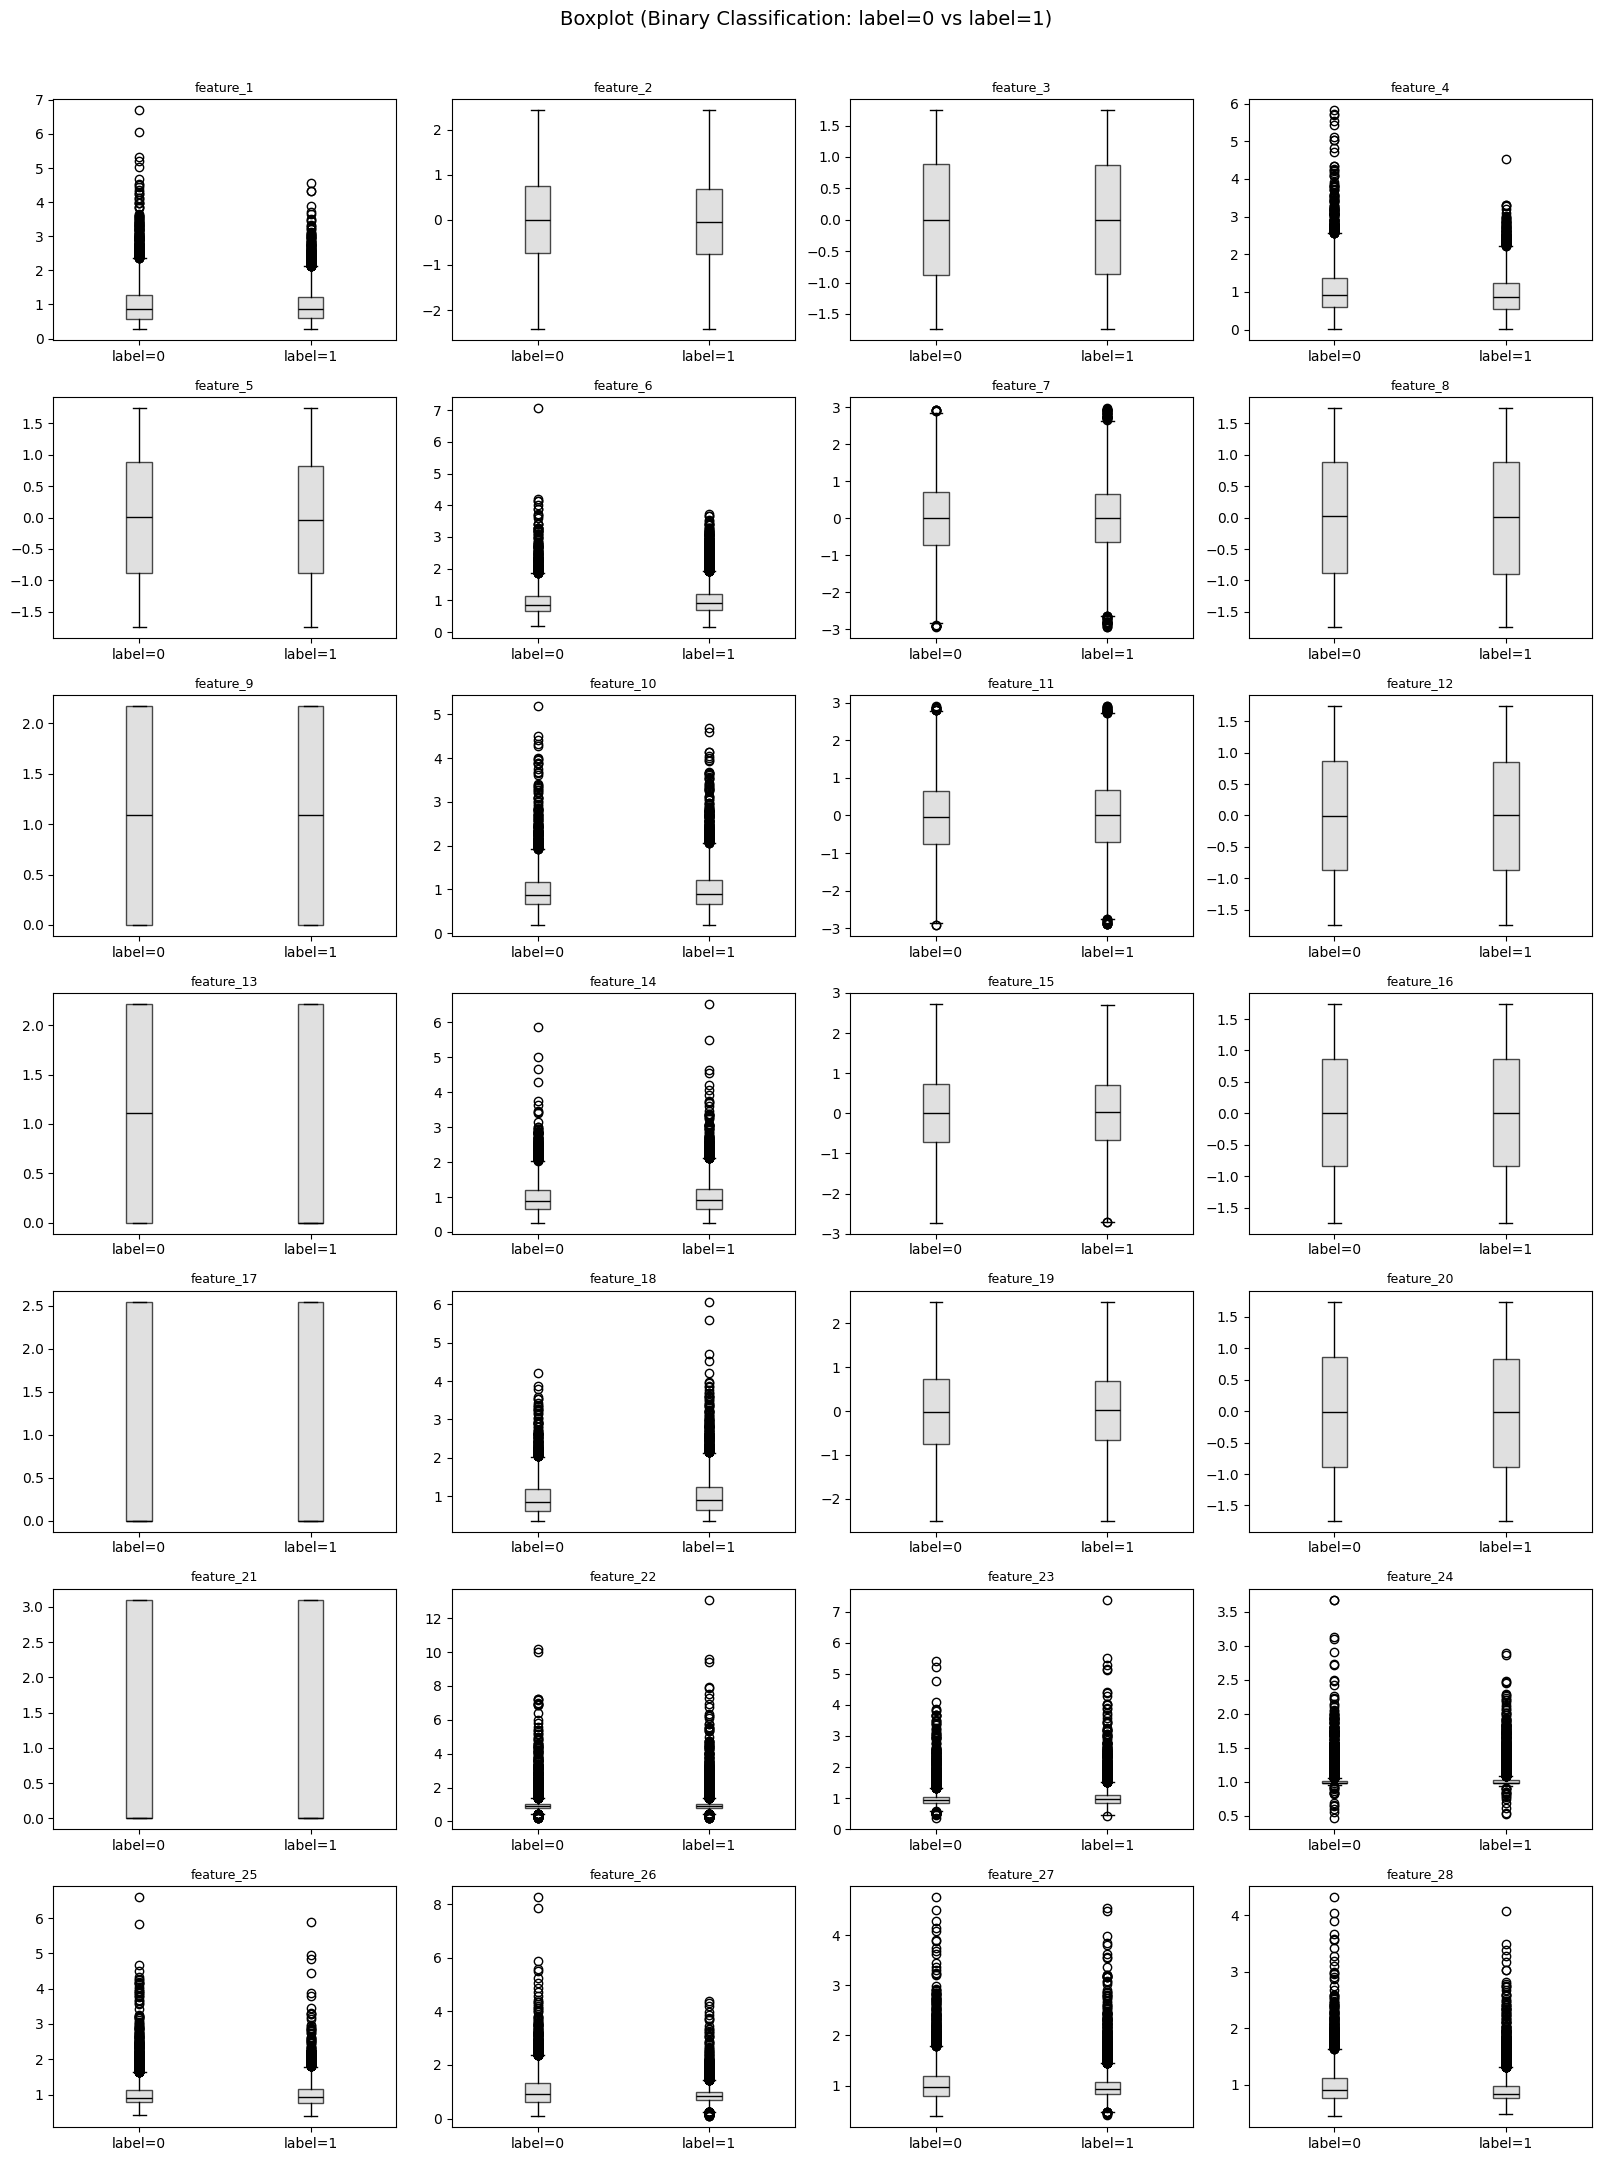

In [6]:
feature_cols = [f'feature_{i}' for i in range(1, 29)]

# IQR ile aykırı değer tespiti
Q1 = df[feature_cols].quantile(0.25)
Q3 = df[feature_cols].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outlier_counts = ((df[feature_cols] < lower) | (df[feature_cols] > upper)).sum()
outlier_pct = (outlier_counts / len(df) * 100).round(2)

outlier_df = pd.DataFrame({
    'Aykırı Sayı': outlier_counts,
    'Aykırı %': outlier_pct
}).sort_values('Aykırı %', ascending=False)

print("Özellik Başına Aykırı Değer:")
display(outlier_df)

# Binary boxplot
fig, axes = plt.subplots(7, 4, figsize=(16, 22))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    data_0 = df[df['label'] == 0][col].dropna()
    data_1 = df[df['label'] == 1][col].dropna()

    axes[i].boxplot(
        [data_0, data_1],
        tick_labels=['label=0', 'label=1'],
        patch_artist=True,
        boxprops=dict(facecolor='lightgray', alpha=0.7),
        medianprops=dict(color='black')
    )

    axes[i].set_title(col, fontsize=9)

plt.suptitle('Boxplot (Binary Classification: label=0 vs label=1)', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


# Clipping ile aykırı değerleri sınırlama
df_clean = df.copy()
df_clean[feature_cols] = df[feature_cols].clip(lower=lower, upper=upper, axis=1)

Aykırı değerler Clipping ile sınırlandırıldı.

Boxplot: Aynı özniteliklerde iki sınıfta da benzer aykırı değerler görülmektedir. Bu grafiklerden gözle görülür bir threshold belirlemek çok zor. Sadece feature_13 ortalamasında belirgin bir fark görülmektedir.

#### 3.1. Verinin Kaydedilmesi

In [7]:
# Temiz veriyi Drive'a kaydet
# clean_path = '/content/drive/MyDrive/HIGGS_5000_clean.csv'
# clean_path = '/content/drive/MyDrive/HIGGS_100k_clean.csv'
clean_path = '/content/drive/MyDrive/HIGGS_10k_clean.csv'
df_clean.to_csv(clean_path, index=False)
print(f"Kaydedildi → {clean_path}")
print(f"Shape: {df_clean.shape}")

Kaydedildi → /content/drive/MyDrive/HIGGS_10k_clean.csv
Shape: (10000, 29)


In [8]:
# 09.06.26 ders notlar:
# MinMaxScaler her fold içinde uygulanacak,
# Normalizasyon nested CV döngüsünün içinde, train_val setine fit,
# Test setine sadece transform uygulanacak. Yeni gelecek tek satırlık veriye normalizasyon yapılamayacağı için..

# feature_cols = [f'feature_{i}' for i in range(1, 29)]
X_raw = df_clean[feature_cols].values
y     = df_clean['label'].values

print(f"Ham veri boyutu: {X_raw.shape}")
print(f"Label dağılımı: {dict(zip(*np.unique(y, return_counts=True)))}")

Ham veri boyutu: (10000, 28)
Label dağılımı: {np.float64(0.0): np.int64(4705), np.float64(1.0): np.int64(5295)}


## 4. Flowchart B

### 4.1. Özellik Seçimi

Filter-Based Feature Selection:

Mutual Information

ANOVA (SVM için)


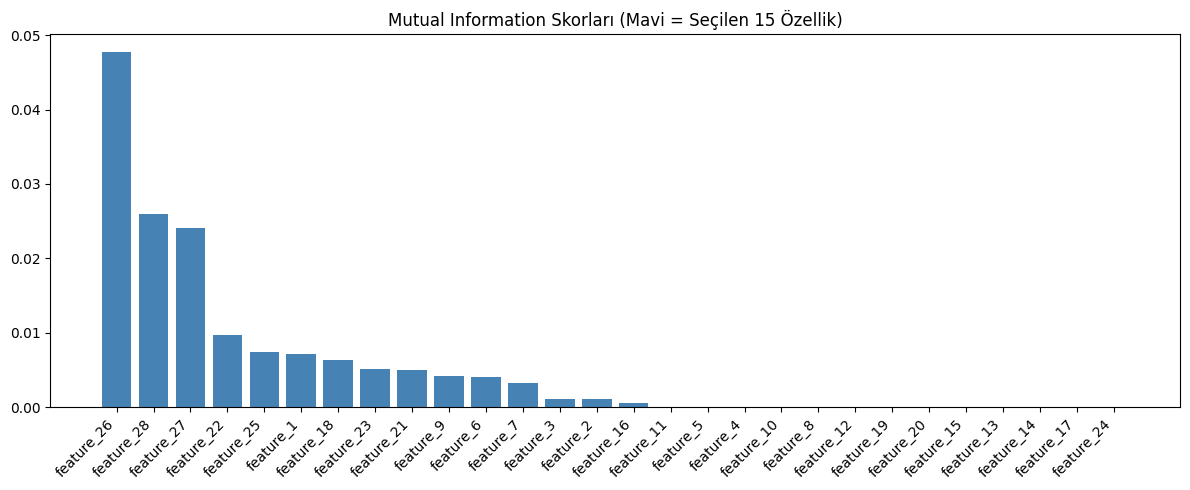

Flowchart B — Seçilen 15 özellik (MI):
['feature_26', 'feature_28', 'feature_27', 'feature_22', 'feature_25', 'feature_1', 'feature_18', 'feature_23', 'feature_21', 'feature_9', 'feature_6', 'feature_7', 'feature_3', 'feature_2', 'feature_16']

Flowchart B — SVM için seçilen 15 özellik (ANOVA):
['feature_26', 'feature_28', 'feature_4', 'feature_6', 'feature_27', 'feature_18', 'feature_13', 'feature_10', 'feature_17', 'feature_1', 'feature_14', 'feature_11', 'feature_23', 'feature_21', 'feature_24']


In [9]:
X_fs = df_clean[feature_cols].values
y_fs = df_clean['label'].values

# MI: KNN, MLP, XGBoost için
mi_selector = SelectKBest(
    score_func=lambda X, y: mutual_info_classif(X, y, random_state=42),
    k=15
)
mi_selector.fit(X_fs, y_fs)
mi_scores = pd.Series(mi_selector.scores_, index=feature_cols).sort_values(ascending=False)
selected_features_mi = mi_scores.head(15).index.tolist()

# Grafik
plt.figure(figsize=(12, 5))
colors = ['steelblue' if f in selected_features_mi else 'lightgray' for f in mi_scores.index]
plt.bar(mi_scores.index, mi_scores.values, color=colors)
plt.xticks(rotation=45, ha='right')
plt.title('Mutual Information Skorları (Mavi = Seçilen 15 Özellik)')
plt.tight_layout()
plt.show()
print(f"Flowchart B — Seçilen 15 özellik (MI):\n{selected_features_mi}")

# ANOVA: SVM için
anova_selector = SelectKBest(score_func=f_classif, k=15)
anova_selector.fit(X_fs, y_fs)
anova_scores = pd.Series(anova_selector.scores_, index=feature_cols).sort_values(ascending=False)
selected_features_anova = anova_scores.head(15).index.tolist()
print(f"\nFlowchart B — SVM için seçilen 15 özellik (ANOVA):\n{selected_features_anova}")

Sonradan fanksiyonla hesaplanan özniteliklerin daha belirleyici olduğu görülmektedir. İlk 5 öznitelik sonradan oluşturulan özniteliklerdir.

Özellik seçimi normalizasyon uygulanmadan ham veri üzerinde yapılmaktadır.

Normalizasyon yalnızca model eğitiminde, her outer fold'un train_val setine ayrı ayrı uygulanacaktır.

## 4.2. Modelleme

### 4.2.1. K-Nearest Neighbors (KNN)

In [10]:
feature_idx_mi = [feature_cols.index(f) for f in selected_features_mi]

outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

def knn_objective(trial, X_train_val, y_train_val, inner_cv):
    k = trial.suggest_int('n_neighbors', 3, 11, step=2)
    model = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(model, X_train_val, y_train_val,
                             cv=inner_cv, scoring='accuracy', n_jobs=-1)
    return scores.mean()

outer_results_knn = []
y_test_all_knn    = []
y_prob_all_knn    = []

for outer_fold, (train_val_idx, test_idx) in enumerate(outer_cv.split(X_raw, y)):
    # Ham veriyi böl
    X_tv_raw, X_test_raw = X_raw[train_val_idx], X_raw[test_idx]
    y_train_val, y_test  = y[train_val_idx],      y[test_idx]

    # Normalizasyon: sadece train_val'e fit
    scaler = MinMaxScaler()
    X_tv_scaled   = scaler.fit_transform(X_tv_raw)
    X_test_scaled = scaler.transform(X_test_raw)

    # Özellik seçimi (global listeden index ile)
    X_train_val = X_tv_scaled[:, feature_idx_mi]
    X_test      = X_test_scaled[:, feature_idx_mi]

    study = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(
        lambda trial, Xtv=X_train_val, ytv=y_train_val: knn_objective(trial, Xtv, ytv, inner_cv),
        n_trials=10
    )

    best_params       = study.best_params
    best_val_accuracy = study.best_value

    best_model = KNeighborsClassifier(n_neighbors=best_params['n_neighbors'])
    best_model.fit(X_train_val, y_train_val)

    y_pred = best_model.predict(X_test)
    y_prob = best_model.predict_proba(X_test)[:, 1]

    y_test_all_knn.append(y_test)
    y_prob_all_knn.append(y_prob)

    outer_results_knn.append({
        'Fold'        : outer_fold + 1,
        'Best k'      : best_params['n_neighbors'],
        'Val Accuracy': round(best_val_accuracy, 4),
        'Accuracy'    : accuracy_score(y_test, y_pred),
        'Precision'   : precision_score(y_test, y_pred),
        'Recall'      : recall_score(y_test, y_pred),
        'F1'          : f1_score(y_test, y_pred),
        'ROC-AUC'     : roc_auc_score(y_test, y_prob)
    })
    print(f"Fold {outer_fold+1} tamamlandı — Best k: {best_params['n_neighbors']}, "
          f"Val Accuracy: {best_val_accuracy:.4f}")

results_knn_b = pd.DataFrame(outer_results_knn)
display(results_knn_b.round(4))

print("\nOrtalama Metrikler (KNN — Flowchart B):")
display(results_knn_b.drop(columns=['Fold','Best k']).mean().round(4).to_frame('Ortalama'))

Fold 1 tamamlandı — Best k: 7, Val Accuracy: 0.6251
Fold 2 tamamlandı — Best k: 11, Val Accuracy: 0.6233
Fold 3 tamamlandı — Best k: 11, Val Accuracy: 0.6221
Fold 4 tamamlandı — Best k: 11, Val Accuracy: 0.6174
Fold 5 tamamlandı — Best k: 11, Val Accuracy: 0.6193


,Fold,Best k,Val Accuracy,Accuracy,Precision,Recall,F1,ROC-AUC
0,1,7,0.6251,0.6255,0.6298,0.7101,0.6676,0.6529
1,2,11,0.6233,0.6255,0.6277,0.7195,0.6705,0.6619
2,3,11,0.6221,0.6250,0.6284,0.7139,0.6684,0.6665
3,4,11,0.6174,0.6445,0.6431,0.7384,0.6875,0.6851
4,5,11,0.6193,0.6135,0.6130,0.7328,0.6675,0.6619



Ortalama Metrikler (KNN — Flowchart B):


,Ortalama
Val Accuracy,0.6214
Accuracy,0.6268
Precision,0.6284
Recall,0.7229
F1,0.6723
ROC-AUC,0.6657


#### 4.2.2.	Support Vector Machine (SVM)

SMV için Özellik Seçimi: ANOVA F-Score



In [11]:
feature_idx_anova = [feature_cols.index(f) for f in selected_features_anova]

def svm_objective(trial, X_train_val, y_train_val, inner_cv):
    C      = trial.suggest_float('C', 0.1, 10, log=True)

    # linear kaldırıldı. sadece rbf.
    kernel = trial.suggest_categorical('kernel', ['rbf'])
    model  = SVC(C=C, kernel=kernel, probability=True, random_state=42)

    # 100.000 satırda iç döngü 20.000 satır ile yapılıyor.
    # 100.000'lik veri çalışmadığı için aşağıdaki iç döngü 10.000 olarak revize edilmiştir.
    inner_sample = 10000
    idx = np.random.choice(len(X_train_val), min(inner_sample, len(X_train_val)), replace=False)

    scores = cross_val_score(model, X_train_val, y_train_val,
                             cv=inner_cv, scoring='accuracy', n_jobs=-1)
    return scores.mean()

outer_results_svm = []
y_test_all_svm    = []
y_prob_all_svm    = []

for outer_fold, (train_val_idx, test_idx) in enumerate(outer_cv.split(X_raw, y)):
    X_tv_raw, X_test_raw = X_raw[train_val_idx], X_raw[test_idx]
    y_train_val, y_test  = y[train_val_idx],      y[test_idx]

    scaler = MinMaxScaler()
    X_tv_scaled   = scaler.fit_transform(X_tv_raw)
    X_test_scaled = scaler.transform(X_test_raw)

    X_train_val = X_tv_scaled[:, feature_idx_anova]
    X_test      = X_test_scaled[:, feature_idx_anova]

    study = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(
        lambda trial, Xtv=X_train_val, ytv=y_train_val: svm_objective(trial, Xtv, ytv, inner_cv),
        n_trials=10
    )

    best_params       = study.best_params
    best_val_accuracy = study.best_value

    best_model = SVC(C=best_params['C'], kernel=best_params['kernel'],
                     probability=True, random_state=42)
    best_model.fit(X_train_val, y_train_val)

    y_pred = best_model.predict(X_test)
    y_prob = best_model.predict_proba(X_test)[:, 1]

    y_test_all_svm.append(y_test)
    y_prob_all_svm.append(y_prob)

    outer_results_svm.append({
        'Fold'        : outer_fold + 1,
        'Best C'      : round(best_params['C'], 4),
        'Best kernel' : best_params['kernel'],
        'Val Accuracy': round(best_val_accuracy, 4),
        'Accuracy'    : accuracy_score(y_test, y_pred),
        'Precision'   : precision_score(y_test, y_pred),
        'Recall'      : recall_score(y_test, y_pred),
        'F1'          : f1_score(y_test, y_pred),
        'ROC-AUC'     : roc_auc_score(y_test, y_prob)
    })
    print(f"Fold {outer_fold+1} tamamlandı — C: {best_params['C']:.4f}, "
          f"kernel: {best_params['kernel']}, Val Accuracy: {best_val_accuracy:.4f}")

results_svm_b = pd.DataFrame(outer_results_svm)
display(results_svm_b.round(4))

print("\nOrtalama Metrikler (SVM — Flowchart B):")
display(results_svm_b.drop(columns=['Fold','Best C','Best kernel']).mean().round(4).to_frame('Ortalama'))

Fold 1 tamamlandı — C: 2.6070, kernel: rbf, Val Accuracy: 0.6751
Fold 2 tamamlandı — C: 2.6070, kernel: rbf, Val Accuracy: 0.6798
Fold 3 tamamlandı — C: 2.9106, kernel: rbf, Val Accuracy: 0.6736
Fold 4 tamamlandı — C: 5.3995, kernel: rbf, Val Accuracy: 0.6771
Fold 5 tamamlandı — C: 2.6070, kernel: rbf, Val Accuracy: 0.6722


,Fold,Best C,Best kernel,Val Accuracy,Accuracy,Precision,Recall,F1,ROC-AUC
0,1,2.6070,rbf,0.6751,0.674,0.6689,0.7611,0.7120,0.7284
1,2,2.6070,rbf,0.6798,0.670,0.6661,0.7554,0.7080,0.7138
2,3,2.9106,rbf,0.6736,0.671,0.6831,0.7063,0.6945,0.7294
3,4,5.3995,rbf,0.6771,0.696,0.6936,0.7630,0.7266,0.7450
4,5,2.6070,rbf,0.6722,0.691,0.6880,0.7620,0.7231,0.7446



Ortalama Metrikler (SVM — Flowchart B):


,Ortalama
Val Accuracy,0.6756
Accuracy,0.6804
Precision,0.6799
Recall,0.7496
F1,0.7128
ROC-AUC,0.7322


100.000 Satır ile Colab Pro'da yüksek RAM ile yapılan çalışmada 24 saat sonunda aşağıdaki 4 döngü tamamlandıktan sonra timeout oluyor. Aşağıdaki değerler 100.000 satır içindir. Üstteki hücre çıktısı 10.000 satır içindir.

Fold 1 tamamlandı — C: 2.6070, kernel: rbf, Val Accuracy: 0.7003

Fold 2 tamamlandı — C: 7.9695, kernel: rbf, Val Accuracy: 0.7014

Fold 3 tamamlandı — C: 7.9695, kernel: rbf, Val Accuracy: 0.7016

Fold 4 tamamlandı — C: 7.9695, kernel: rbf, Val Accuracy: 0.7021

#### 4.2.3.	Multi-Layer Perceptron (MLP)

In [13]:
hl_map = {
    '50'    : (50,),
    '100'   : (100,),
    '50_50' : (50, 50),
    '100_50': (100, 50)
}

def mlp_objective(trial, X_train_val, y_train_val, inner_cv):
    hl_key     = trial.suggest_categorical('hidden_layer_sizes', list(hl_map.keys()))
    activation = trial.suggest_categorical('activation', ['relu', 'tanh'])
    alpha      = trial.suggest_float('alpha', 1e-4, 1e-1, log=True)
    lr         = trial.suggest_categorical('learning_rate_init', [0.001, 0.01])
    model = MLPClassifier(
        hidden_layer_sizes=hl_map[hl_key],
        activation=activation,
        alpha=alpha,
        learning_rate_init=lr,
        max_iter=1000,
        early_stopping=True,
        random_state=42
    )
    scores = cross_val_score(model, X_train_val, y_train_val,
                             cv=inner_cv, scoring='accuracy', n_jobs=-1)
    return scores.mean()

outer_results_mlp = []
y_test_all_mlp    = []
y_prob_all_mlp    = []

for outer_fold, (train_val_idx, test_idx) in enumerate(outer_cv.split(X_raw, y)):
    X_tv_raw, X_test_raw = X_raw[train_val_idx], X_raw[test_idx]
    y_train_val, y_test  = y[train_val_idx],      y[test_idx]

    scaler = MinMaxScaler()
    X_tv_scaled   = scaler.fit_transform(X_tv_raw)
    X_test_scaled = scaler.transform(X_test_raw)

    X_train_val = X_tv_scaled[:, feature_idx_mi]
    X_test      = X_test_scaled[:, feature_idx_mi]

    study = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(
        lambda trial, Xtv=X_train_val, ytv=y_train_val: mlp_objective(trial, Xtv, ytv, inner_cv),
        n_trials=20
    )

    best_params       = study.best_params
    best_val_accuracy = study.best_value

    best_model = MLPClassifier(
        hidden_layer_sizes=hl_map[best_params['hidden_layer_sizes']],
        activation=best_params['activation'],
        alpha=best_params['alpha'],
        learning_rate_init=best_params['learning_rate_init'],
        max_iter=1000,
        early_stopping=True,
        random_state=42
    )
    best_model.fit(X_train_val, y_train_val)

    y_pred = best_model.predict(X_test)
    y_prob = best_model.predict_proba(X_test)[:, 1]

    y_test_all_mlp.append(y_test)
    y_prob_all_mlp.append(y_prob)

    outer_results_mlp.append({
        'Fold'         : outer_fold + 1,
        'Hidden Layers': best_params['hidden_layer_sizes'],
        'Activation'   : best_params['activation'],
        'Alpha'        : round(best_params['alpha'], 6),
        'LR'           : best_params['learning_rate_init'],
        'Val Accuracy' : round(best_val_accuracy, 4),
        'Accuracy'     : accuracy_score(y_test, y_pred),
        'Precision'    : precision_score(y_test, y_pred),
        'Recall'       : recall_score(y_test, y_pred),
        'F1'           : f1_score(y_test, y_pred),
        'ROC-AUC'      : roc_auc_score(y_test, y_prob)
    })
    print(f"Fold {outer_fold+1} tamamlandı — "
          f"Layers: {best_params['hidden_layer_sizes']}, "
          f"Activation: {best_params['activation']}, "
          f"Val Accuracy: {best_val_accuracy:.4f}")

results_mlp_b = pd.DataFrame(outer_results_mlp)
display(results_mlp_b.round(4))

print("\nOrtalama Metrikler (MLP — Flowchart B):")
display(results_mlp_b.drop(
    columns=['Fold','Hidden Layers','Activation','Alpha','LR']
).mean().round(4).to_frame('Ortalama'))

Fold 1 tamamlandı — Layers: 100, Activation: relu, Val Accuracy: 0.6838
Fold 2 tamamlandı — Layers: 100_50, Activation: relu, Val Accuracy: 0.6845
Fold 3 tamamlandı — Layers: 100_50, Activation: relu, Val Accuracy: 0.6836
Fold 4 tamamlandı — Layers: 100_50, Activation: relu, Val Accuracy: 0.6805
Fold 5 tamamlandı — Layers: 100_50, Activation: relu, Val Accuracy: 0.6825


,Fold,Hidden Layers,Activation,Alpha,LR,Val Accuracy,Accuracy,Precision,Recall,F1,ROC-AUC
0,1,100,relu,0.0012,0.01,0.6838,0.6745,0.6627,0.7847,0.7185,0.7406
1,2,100_50,relu,0.0005,0.01,0.6845,0.6795,0.6833,0.7356,0.7085,0.7371
2,3,100_50,relu,0.0411,0.01,0.6836,0.6985,0.7069,0.7356,0.7210,0.7623
3,4,100_50,relu,0.0005,0.01,0.6805,0.6890,0.7033,0.7139,0.7085,0.7602
4,5,100_50,relu,0.0207,0.01,0.6825,0.6930,0.6790,0.7970,0.7333,0.7568



Ortalama Metrikler (MLP — Flowchart B):


,Ortalama
Val Accuracy,0.6830
Accuracy,0.6869
Precision,0.6870
Recall,0.7534
F1,0.7180
ROC-AUC,0.7514


#### 4.2.4.	XGBoost

In [14]:
def xgb_objective(trial, X_train_val, y_train_val, inner_cv):
    params = {
        'n_estimators'    : trial.suggest_int('n_estimators', 100, 500, step=100),
        'max_depth'       : trial.suggest_int('max_depth', 3, 8),
        'learning_rate'   : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample'       : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
    }
    model = XGBClassifier(**params, eval_metric='logloss', random_state=42, n_jobs=-1)
    scores = cross_val_score(model, X_train_val, y_train_val,
                             cv=inner_cv, scoring='accuracy', n_jobs=-1)
    return scores.mean()

outer_results_xgb = []
y_test_all_xgb    = []
y_prob_all_xgb    = []

for outer_fold, (train_val_idx, test_idx) in enumerate(outer_cv.split(X_raw, y)):
    X_tv_raw, X_test_raw = X_raw[train_val_idx], X_raw[test_idx]
    y_train_val, y_test  = y[train_val_idx],      y[test_idx]

    scaler = MinMaxScaler()
    X_tv_scaled   = scaler.fit_transform(X_tv_raw)
    X_test_scaled = scaler.transform(X_test_raw)

    X_train_val = X_tv_scaled[:, feature_idx_mi]
    X_test      = X_test_scaled[:, feature_idx_mi]

    study = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(
        lambda trial, Xtv=X_train_val, ytv=y_train_val: xgb_objective(trial, Xtv, ytv, inner_cv),
        n_trials=20
    )

    best_params       = study.best_params
    best_val_accuracy = study.best_value

    best_model = XGBClassifier(
        **best_params, eval_metric='logloss', random_state=42, n_jobs=-1
    )
    best_model.fit(X_train_val, y_train_val)

    y_pred = best_model.predict(X_test)
    y_prob = best_model.predict_proba(X_test)[:, 1]

    y_test_all_xgb.append(y_test)
    y_prob_all_xgb.append(y_prob)

    outer_results_xgb.append({
        'Fold'          : outer_fold + 1,
        'n_estimators'  : best_params['n_estimators'],
        'max_depth'     : best_params['max_depth'],
        'learning_rate' : round(best_params['learning_rate'], 4),
        'subsample'     : round(best_params['subsample'], 4),
        'colsample'     : round(best_params['colsample_bytree'], 4),
        'Val Accuracy'  : round(best_val_accuracy, 4),
        'Accuracy'      : accuracy_score(y_test, y_pred),
        'Precision'     : precision_score(y_test, y_pred),
        'Recall'        : recall_score(y_test, y_pred),
        'F1'            : f1_score(y_test, y_pred),
        'ROC-AUC'       : roc_auc_score(y_test, y_prob)
    })
    print(f"Fold {outer_fold+1} tamamlandı — "
          f"n_est: {best_params['n_estimators']}, "
          f"depth: {best_params['max_depth']}, "
          f"lr: {best_params['learning_rate']:.4f}, "
          f"Val Accuracy: {best_val_accuracy:.4f}")

results_xgb_b = pd.DataFrame(outer_results_xgb)
display(results_xgb_b.round(4))

print("\nOrtalama Metrikler (XGBoost — Flowchart B):")
display(results_xgb_b.drop(
    columns=['Fold','n_estimators','max_depth','learning_rate','subsample','colsample']
).mean().round(4).to_frame('Ortalama'))

Fold 1 tamamlandı — n_est: 100, depth: 4, lr: 0.0596, Val Accuracy: 0.7040
Fold 2 tamamlandı — n_est: 500, depth: 6, lr: 0.0170, Val Accuracy: 0.7108
Fold 3 tamamlandı — n_est: 400, depth: 4, lr: 0.0575, Val Accuracy: 0.7081
Fold 4 tamamlandı — n_est: 500, depth: 4, lr: 0.0139, Val Accuracy: 0.7100
Fold 5 tamamlandı — n_est: 500, depth: 3, lr: 0.0192, Val Accuracy: 0.7045


,Fold,n_estimators,max_depth,learning_rate,subsample,colsample,Val Accuracy,Accuracy,Precision,Recall,F1,ROC-AUC
0,1,100,4,0.0596,0.7728,0.7165,0.7040,0.7005,0.7091,0.7365,0.7226,0.7785
1,2,500,6,0.0170,0.6077,0.7600,0.7108,0.6985,0.7032,0.7450,0.7235,0.7754
2,3,400,4,0.0575,0.8370,0.6186,0.7081,0.6885,0.7080,0.7007,0.7043,0.7733
3,4,500,4,0.0139,0.8737,0.7761,0.7100,0.7090,0.7186,0.7403,0.7293,0.7843
4,5,500,3,0.0192,0.7326,0.7849,0.7045,0.7150,0.7193,0.7573,0.7378,0.7857



Ortalama Metrikler (XGBoost — Flowchart B):


,Ortalama
Val Accuracy,0.7075
Accuracy,0.7023
Precision,0.7116
Recall,0.7360
F1,0.7235
ROC-AUC,0.7795


## 5. Flowchart A

### 5.1. Modelleme

#### 5.1.1. KNN

In [15]:
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)


# Sabit hiperparametreler
KNN_K = 5

def knn_a_objective(trial, X_train_val, y_train_val, inner_cv):
    k_features = trial.suggest_int('k_features', 5, 20)

    pipeline = Pipeline([
        ('scaler',    MinMaxScaler()),
        ('selector',  SelectKBest(
                          score_func=mutual_info_classif,
                          k=k_features
                      )),
        ('model',     KNeighborsClassifier(n_neighbors=KNN_K))
    ])

    scores = cross_val_score(pipeline, X_train_val, y_train_val,
                             cv=inner_cv, scoring='accuracy', n_jobs=-1)
    return scores.mean()

outer_results_knn_a = []
y_test_all_knn_a    = []
y_prob_all_knn_a    = []

for outer_fold, (train_val_idx, test_idx) in enumerate(outer_cv.split(X_raw, y)):
    X_tv_raw, X_test_raw = X_raw[train_val_idx], X_raw[test_idx]
    y_train_val, y_test  = y[train_val_idx],      y[test_idx]

    study = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler())
    study.optimize(
        lambda trial, Xtv=X_tv_raw, ytv=y_train_val: knn_a_objective(trial, Xtv, ytv, inner_cv),
        n_trials=10
    )

    best_k_features   = study.best_params['k_features']
    best_val_accuracy = study.best_value

    # En iyi k_features ile tüm train_val üzerinde yeniden eğit
    best_pipeline = Pipeline([
        ('scaler',   MinMaxScaler()),
        ('selector', SelectKBest(
                         score_func=mutual_info_classif,
                         k=best_k_features
                     )),
        ('model',    KNeighborsClassifier(n_neighbors=KNN_K))
    ])
    best_pipeline.fit(X_tv_raw, y_train_val)

    y_pred = best_pipeline.predict(X_test_raw)
    y_prob = best_pipeline.predict_proba(X_test_raw)[:, 1]

    # Seçilen özellikler
    selector       = best_pipeline.named_steps['selector']
    selected_mask  = selector.get_support()
    selected_feats = [feature_cols[i] for i, m in enumerate(selected_mask) if m]

    y_test_all_knn_a.append(y_test)
    y_prob_all_knn_a.append(y_prob)

    outer_results_knn_a.append({
        'Fold'           : outer_fold + 1,
        'k_features'     : best_k_features,
        'Seçilen Özellik': str(selected_feats),
        'Val Accuracy'   : round(best_val_accuracy, 4),
        'Accuracy'       : accuracy_score(y_test, y_pred),
        'Precision'      : precision_score(y_test, y_pred),
        'Recall'         : recall_score(y_test, y_pred),
        'F1'             : f1_score(y_test, y_pred),
        'ROC-AUC'        : roc_auc_score(y_test, y_prob)
    })
    print(f"Fold {outer_fold+1} tamamlandı — "
          f"k_features: {best_k_features}, "
          f"Val Accuracy: {best_val_accuracy:.4f}")

results_knn_a = pd.DataFrame(outer_results_knn_a)
display(results_knn_a.round(4))

print("\nOrtalama Metrikler (KNN — Flowchart A):")
display(results_knn_a.drop(
    columns=['Fold','k_features','Seçilen Özellik']
).mean().round(4).to_frame('Ortalama'))

Fold 1 tamamlandı — k_features: 10, Val Accuracy: 0.6236
Fold 2 tamamlandı — k_features: 6, Val Accuracy: 0.6409
Fold 3 tamamlandı — k_features: 7, Val Accuracy: 0.6304
Fold 4 tamamlandı — k_features: 8, Val Accuracy: 0.6321
Fold 5 tamamlandı — k_features: 8, Val Accuracy: 0.6270


,Fold,k_features,Seçilen Özellik,Val Accuracy,Accuracy,Precision,Recall,F1,ROC-AUC
0,1,10,"['feature_2', 'feature_6', 'feature_9', 'featu...",0.6236,0.641,0.6502,0.6969,0.6727,0.6780
1,2,6,"['feature_1', 'feature_18', 'feature_25', 'fea...",0.6409,0.628,0.6345,0.7016,0.6664,0.6696
2,3,7,"['feature_13', 'feature_16', 'feature_23', 'fe...",0.6304,0.646,0.6580,0.6903,0.6737,0.6893
3,4,8,"['feature_14', 'feature_22', 'feature_23', 'fe...",0.6321,0.654,0.6605,0.7129,0.6857,0.6959
4,5,8,"['feature_1', 'feature_16', 'feature_17', 'fea...",0.6270,0.612,0.6213,0.6846,0.6514,0.6505



Ortalama Metrikler (KNN — Flowchart A):


,Ortalama
Val Accuracy,0.6308
Accuracy,0.6362
Precision,0.6449
Recall,0.6973
F1,0.6700
ROC-AUC,0.6767


#### 5.1.2. SVM

In [16]:
# Sabit hiperparametreler
SVM_C      = 1.0
SVM_KERNEL = 'rbf'

def svm_a_objective(trial, X_train_val, y_train_val, inner_cv):
    k_features = trial.suggest_int('k_features', 5, 20)

    pipeline = Pipeline([
        ('scaler',   MinMaxScaler()),
        ('selector', SelectKBest(score_func=f_classif, k=k_features)),
        ('model',    SVC(C=SVM_C, kernel=SVM_KERNEL, probability=True, random_state=42))
    ])

    scores = cross_val_score(pipeline, X_train_val, y_train_val,
                             cv=inner_cv, scoring='accuracy', n_jobs=-1)
    return scores.mean()

outer_results_svm_a = []
y_test_all_svm_a    = []
y_prob_all_svm_a    = []

for outer_fold, (train_val_idx, test_idx) in enumerate(outer_cv.split(X_raw, y)):
    X_tv_raw, X_test_raw = X_raw[train_val_idx], X_raw[test_idx]
    y_train_val, y_test  = y[train_val_idx],      y[test_idx]

    study = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler())
    study.optimize(
        lambda trial, Xtv=X_tv_raw, ytv=y_train_val: svm_a_objective(trial, Xtv, ytv, inner_cv),
        n_trials=10
    )

    best_k_features   = study.best_params['k_features']
    best_val_accuracy = study.best_value

    best_pipeline = Pipeline([
        ('scaler',   MinMaxScaler()),
        ('selector', SelectKBest(score_func=f_classif, k=best_k_features)),
        ('model',    SVC(C=SVM_C, kernel=SVM_KERNEL, probability=True, random_state=42))
    ])
    best_pipeline.fit(X_tv_raw, y_train_val)

    y_pred = best_pipeline.predict(X_test_raw)
    y_prob = best_pipeline.predict_proba(X_test_raw)[:, 1]

    selector      = best_pipeline.named_steps['selector']
    selected_mask = selector.get_support()
    selected_feats = [feature_cols[i] for i, m in enumerate(selected_mask) if m]

    y_test_all_svm_a.append(y_test)
    y_prob_all_svm_a.append(y_prob)

    outer_results_svm_a.append({
        'Fold'           : outer_fold + 1,
        'k_features'     : best_k_features,
        'Seçilen Özellik': str(selected_feats),
        'Val Accuracy'   : round(best_val_accuracy, 4),
        'Accuracy'       : accuracy_score(y_test, y_pred),
        'Precision'      : precision_score(y_test, y_pred),
        'Recall'         : recall_score(y_test, y_pred),
        'F1'             : f1_score(y_test, y_pred),
        'ROC-AUC'        : roc_auc_score(y_test, y_prob)
    })
    print(f"Fold {outer_fold+1} tamamlandı — "
          f"k_features: {best_k_features}, "
          f"Val Accuracy: {best_val_accuracy:.4f}")

results_svm_a = pd.DataFrame(outer_results_svm_a)
display(results_svm_a.round(4))

print("\nOrtalama Metrikler (SVM — Flowchart A):")
display(results_svm_a.drop(
    columns=['Fold','k_features','Seçilen Özellik']
).mean().round(4).to_frame('Ortalama'))

Fold 1 tamamlandı — k_features: 8, Val Accuracy: 0.6776
Fold 2 tamamlandı — k_features: 6, Val Accuracy: 0.6824
Fold 3 tamamlandı — k_features: 7, Val Accuracy: 0.6804
Fold 4 tamamlandı — k_features: 10, Val Accuracy: 0.6800
Fold 5 tamamlandı — k_features: 6, Val Accuracy: 0.6756


,Fold,k_features,Seçilen Özellik,Val Accuracy,Accuracy,Precision,Recall,F1,ROC-AUC
0,1,8,"['feature_4', 'feature_6', 'feature_10', 'feat...",0.6776,0.6760,0.6758,0.7460,0.7092,0.7369
1,2,6,"['feature_4', 'feature_6', 'feature_13', 'feat...",0.6824,0.6575,0.6609,0.7252,0.6916,0.7207
2,3,7,"['feature_4', 'feature_6', 'feature_10', 'feat...",0.6804,0.6800,0.6990,0.6950,0.6970,0.7336
3,4,10,"['feature_1', 'feature_4', 'feature_6', 'featu...",0.6800,0.6975,0.6991,0.7526,0.7249,0.7539
4,5,6,"['feature_4', 'feature_6', 'feature_18', 'feat...",0.6756,0.6885,0.6940,0.7365,0.7146,0.7452



Ortalama Metrikler (SVM — Flowchart A):


,Ortalama
Val Accuracy,0.6792
Accuracy,0.6799
Precision,0.6857
Recall,0.7311
F1,0.7074
ROC-AUC,0.7381


#### 5.1.3. MLP

In [17]:
# Sabit hiperparametreler
MLP_HIDDEN     = (100,)
MLP_ACTIVATION = 'relu'
MLP_ALPHA      = 0.001

def mlp_a_objective(trial, X_train_val, y_train_val, inner_cv):
    k_features = trial.suggest_int('k_features', 5, 20)

    pipeline = Pipeline([
        ('scaler',   MinMaxScaler()),
        ('selector', SelectKBest(score_func=mutual_info_classif, k=k_features)),
        ('model',    MLPClassifier(
                         hidden_layer_sizes=MLP_HIDDEN,
                         activation=MLP_ACTIVATION,
                         alpha=MLP_ALPHA,
                         max_iter=1000,
                         early_stopping=True,
                         random_state=42
                     ))
    ])

    scores = cross_val_score(pipeline, X_train_val, y_train_val,
                             cv=inner_cv, scoring='accuracy', n_jobs=-1)
    return scores.mean()

outer_results_mlp_a = []
y_test_all_mlp_a    = []
y_prob_all_mlp_a    = []

for outer_fold, (train_val_idx, test_idx) in enumerate(outer_cv.split(X_raw, y)):
    X_tv_raw, X_test_raw = X_raw[train_val_idx], X_raw[test_idx]
    y_train_val, y_test  = y[train_val_idx],      y[test_idx]

    study = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler())
    study.optimize(
        lambda trial, Xtv=X_tv_raw, ytv=y_train_val: mlp_a_objective(trial, Xtv, ytv, inner_cv),
        n_trials=10
    )

    best_k_features   = study.best_params['k_features']
    best_val_accuracy = study.best_value

    best_pipeline = Pipeline([
        ('scaler',   MinMaxScaler()),
        ('selector', SelectKBest(score_func=mutual_info_classif, k=best_k_features)),
        ('model',    MLPClassifier(
                         hidden_layer_sizes=MLP_HIDDEN,
                         activation=MLP_ACTIVATION,
                         alpha=MLP_ALPHA,
                         max_iter=1000,
                         early_stopping=True,
                         random_state=42
                     ))
    ])
    best_pipeline.fit(X_tv_raw, y_train_val)

    y_pred = best_pipeline.predict(X_test_raw)
    y_prob = best_pipeline.predict_proba(X_test_raw)[:, 1]

    selector       = best_pipeline.named_steps['selector']
    selected_mask  = selector.get_support()
    selected_feats = [feature_cols[i] for i, m in enumerate(selected_mask) if m]

    y_test_all_mlp_a.append(y_test)
    y_prob_all_mlp_a.append(y_prob)

    outer_results_mlp_a.append({
        'Fold'           : outer_fold + 1,
        'k_features'     : best_k_features,
        'Seçilen Özellik': str(selected_feats),
        'Val Accuracy'   : round(best_val_accuracy, 4),
        'Accuracy'       : accuracy_score(y_test, y_pred),
        'Precision'      : precision_score(y_test, y_pred),
        'Recall'         : recall_score(y_test, y_pred),
        'F1'             : f1_score(y_test, y_pred),
        'ROC-AUC'        : roc_auc_score(y_test, y_prob)
    })
    print(f"Fold {outer_fold+1} tamamlandı — "
          f"k_features: {best_k_features}, "
          f"Val Accuracy: {best_val_accuracy:.4f}")

results_mlp_a = pd.DataFrame(outer_results_mlp_a)
display(results_mlp_a.round(4))

print("\nOrtalama Metrikler (MLP — Flowchart A):")
display(results_mlp_a.drop(
    columns=['Fold','k_features','Seçilen Özellik']
).mean().round(4).to_frame('Ortalama'))

Fold 1 tamamlandı — k_features: 14, Val Accuracy: 0.6655
Fold 2 tamamlandı — k_features: 11, Val Accuracy: 0.6557
Fold 3 tamamlandı — k_features: 5, Val Accuracy: 0.6666
Fold 4 tamamlandı — k_features: 9, Val Accuracy: 0.6674
Fold 5 tamamlandı — k_features: 11, Val Accuracy: 0.6701


,Fold,k_features,Seçilen Özellik,Val Accuracy,Accuracy,Precision,Recall,F1,ROC-AUC
0,1,14,"['feature_1', 'feature_2', 'feature_5', 'featu...",0.6655,0.6645,0.6661,0.7347,0.6987,0.7250
1,2,11,"['feature_1', 'feature_6', 'feature_10', 'feat...",0.6557,0.6680,0.6791,0.7073,0.6929,0.7205
2,3,5,"['feature_16', 'feature_23', 'feature_26', 'fe...",0.6666,0.6665,0.6795,0.7007,0.6899,0.7237
3,4,9,"['feature_1', 'feature_14', 'feature_19', 'fea...",0.6674,0.6865,0.6888,0.7441,0.7154,0.7409
4,5,11,"['feature_1', 'feature_4', 'feature_9', 'featu...",0.6701,0.6595,0.6549,0.7545,0.7012,0.7191



Ortalama Metrikler (MLP — Flowchart A):


,Ortalama
Val Accuracy,0.6651
Accuracy,0.6690
Precision,0.6737
Recall,0.7282
F1,0.6996
ROC-AUC,0.7258


#### 5.1.4. XGBoost

In [18]:
# Sabit hiperparametreler
XGB_N_EST  = 200
XGB_DEPTH  = 5
XGB_LR     = 0.1

def xgb_a_objective(trial, X_train_val, y_train_val, inner_cv):
    k_features = trial.suggest_int('k_features', 5, 20)

    pipeline = Pipeline([
        ('scaler',   MinMaxScaler()),
        ('selector', SelectKBest(score_func=mutual_info_classif, k=k_features)),
        ('model',    XGBClassifier(
                         n_estimators=XGB_N_EST,
                         max_depth=XGB_DEPTH,
                         learning_rate=XGB_LR,
                         eval_metric='logloss',
                         random_state=42,
                         n_jobs=-1
                     ))
    ])

    scores = cross_val_score(pipeline, X_train_val, y_train_val,
                             cv=inner_cv, scoring='accuracy', n_jobs=-1)
    return scores.mean()

outer_results_xgb_a = []
y_test_all_xgb_a    = []
y_prob_all_xgb_a    = []

for outer_fold, (train_val_idx, test_idx) in enumerate(outer_cv.split(X_raw, y)):
    X_tv_raw, X_test_raw = X_raw[train_val_idx], X_raw[test_idx]
    y_train_val, y_test  = y[train_val_idx],      y[test_idx]

    study = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler())
    study.optimize(
        lambda trial, Xtv=X_tv_raw, ytv=y_train_val: xgb_a_objective(trial, Xtv, ytv, inner_cv),
        n_trials=10
    )

    best_k_features   = study.best_params['k_features']
    best_val_accuracy = study.best_value

    best_pipeline = Pipeline([
        ('scaler',   MinMaxScaler()),
        ('selector', SelectKBest(score_func=mutual_info_classif, k=best_k_features)),
        ('model',    XGBClassifier(
                         n_estimators=XGB_N_EST,
                         max_depth=XGB_DEPTH,
                         learning_rate=XGB_LR,
                         eval_metric='logloss',
                         random_state=42,
                         n_jobs=-1
                     ))
    ])
    best_pipeline.fit(X_tv_raw, y_train_val)

    y_pred = best_pipeline.predict(X_test_raw)
    y_prob = best_pipeline.predict_proba(X_test_raw)[:, 1]

    selector       = best_pipeline.named_steps['selector']
    selected_mask  = selector.get_support()
    selected_feats = [feature_cols[i] for i, m in enumerate(selected_mask) if m]

    y_test_all_xgb_a.append(y_test)
    y_prob_all_xgb_a.append(y_prob)

    outer_results_xgb_a.append({
        'Fold'           : outer_fold + 1,
        'k_features'     : best_k_features,
        'Seçilen Özellik': str(selected_feats),
        'Val Accuracy'   : round(best_val_accuracy, 4),
        'Accuracy'       : accuracy_score(y_test, y_pred),
        'Precision'      : precision_score(y_test, y_pred),
        'Recall'         : recall_score(y_test, y_pred),
        'F1'             : f1_score(y_test, y_pred),
        'ROC-AUC'        : roc_auc_score(y_test, y_prob)
    })
    print(f"Fold {outer_fold+1} tamamlandı — "
          f"k_features: {best_k_features}, "
          f"Val Accuracy: {best_val_accuracy:.4f}")

results_xgb_a = pd.DataFrame(outer_results_xgb_a)
display(results_xgb_a.round(4))

print("\nOrtalama Metrikler (XGBoost — Flowchart A):")
display(results_xgb_a.drop(
    columns=['Fold','k_features','Seçilen Özellik']
).mean().round(4).to_frame('Ortalama'))

Fold 1 tamamlandı — k_features: 20, Val Accuracy: 0.6913
Fold 2 tamamlandı — k_features: 19, Val Accuracy: 0.6994
Fold 3 tamamlandı — k_features: 16, Val Accuracy: 0.6881
Fold 4 tamamlandı — k_features: 14, Val Accuracy: 0.6849
Fold 5 tamamlandı — k_features: 17, Val Accuracy: 0.6919


,Fold,k_features,Seçilen Özellik,Val Accuracy,Accuracy,Precision,Recall,F1,ROC-AUC
0,1,20,"['feature_1', 'feature_2', 'feature_3', 'featu...",0.6913,0.7010,0.7105,0.7347,0.7224,0.7736
1,2,19,"['feature_1', 'feature_2', 'feature_3', 'featu...",0.6994,0.6930,0.7014,0.7318,0.7163,0.7621
2,3,16,"['feature_1', 'feature_9', 'feature_13', 'feat...",0.6881,0.6890,0.7079,0.7025,0.7052,0.7545
3,4,14,"['feature_1', 'feature_5', 'feature_10', 'feat...",0.6849,0.6895,0.7005,0.7224,0.7113,0.7708
4,5,17,"['feature_1', 'feature_2', 'feature_4', 'featu...",0.6919,0.6895,0.6973,0.7309,0.7137,0.7642



Ortalama Metrikler (XGBoost — Flowchart A):


,Ortalama
Val Accuracy,0.6911
Accuracy,0.6924
Precision,0.7035
Recall,0.7245
F1,0.7138
ROC-AUC,0.7650


## 6. Değerlendirme ve Sonuç

### 6.1. Genel Metrik Karşılaştırma Tablosu:

Flowchart A vs Flowchart B

In [19]:
metric_results = []

metric_sources = {
    'KNN'    : {'A': results_knn_a,  'B': results_knn_b},
    'SVM'    : {'A': results_svm_a,  'B': results_svm_b},
    'MLP'    : {'A': results_mlp_a,  'B': results_mlp_b},
    'XGBoost': {'A': results_xgb_a,  'B': results_xgb_b},
}

drop_cols = {
    'KNN'    : ['Fold', 'Best k',       'Val Accuracy', 'Seçilen Özellik', 'k_features'],
    'SVM'    : ['Fold', 'Best C', 'Best kernel', 'Val Accuracy', 'Seçilen Özellik', 'k_features'],
    'MLP'    : ['Fold', 'Hidden Layers', 'Activation', 'Alpha', 'LR', 'Val Accuracy', 'Seçilen Özellik', 'k_features'],
    'XGBoost': ['Fold', 'n_estimators', 'max_depth', 'learning_rate', 'subsample', 'colsample', 'Val Accuracy', 'Seçilen Özellik', 'k_features'],
}

for model_name, flows in metric_sources.items():
    for flow, results_df in flows.items():
        drop = [c for c in drop_cols[model_name] if c in results_df.columns]
        means = results_df.drop(columns=drop).mean()
        metric_results.append({
            'Model'    : model_name,
            'Flowchart': flow,
            'Accuracy' : round(means['Accuracy'],  4),
            'Precision': round(means['Precision'], 4),
            'Recall'   : round(means['Recall'],    4),
            'F1'       : round(means['F1'],        4),
            'ROC-AUC'  : round(means['ROC-AUC'],   4),
        })

metric_df = pd.DataFrame(metric_results).sort_values(
    ['Model', 'Flowchart']
).reset_index(drop=True)

display(metric_df.style.background_gradient(
    subset=['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC'],
    cmap='RdYlGn'
))

,Model,Flowchart,Accuracy,Precision,Recall,F1,ROC-AUC
0,KNN,A,0.636200,0.644900,0.697300,0.670000,0.676700
1,KNN,B,0.626800,0.628400,0.722900,0.672300,0.665700
2,MLP,A,0.669000,0.673700,0.728200,0.699600,0.725800
3,MLP,B,0.686900,0.687000,0.753400,0.718000,0.751400
4,SVM,A,0.679900,0.685700,0.731100,0.707400,0.738100
5,SVM,B,0.680400,0.679900,0.749600,0.712800,0.732200
6,XGBoost,A,0.692400,0.703500,0.724500,0.713800,0.765000
7,XGBoost,B,0.702300,0.711600,0.736000,0.723500,0.779500


### 6.2. ROC Eğrileri:

Flowchart A vs Flowchart B (OVA, Model Bazında)

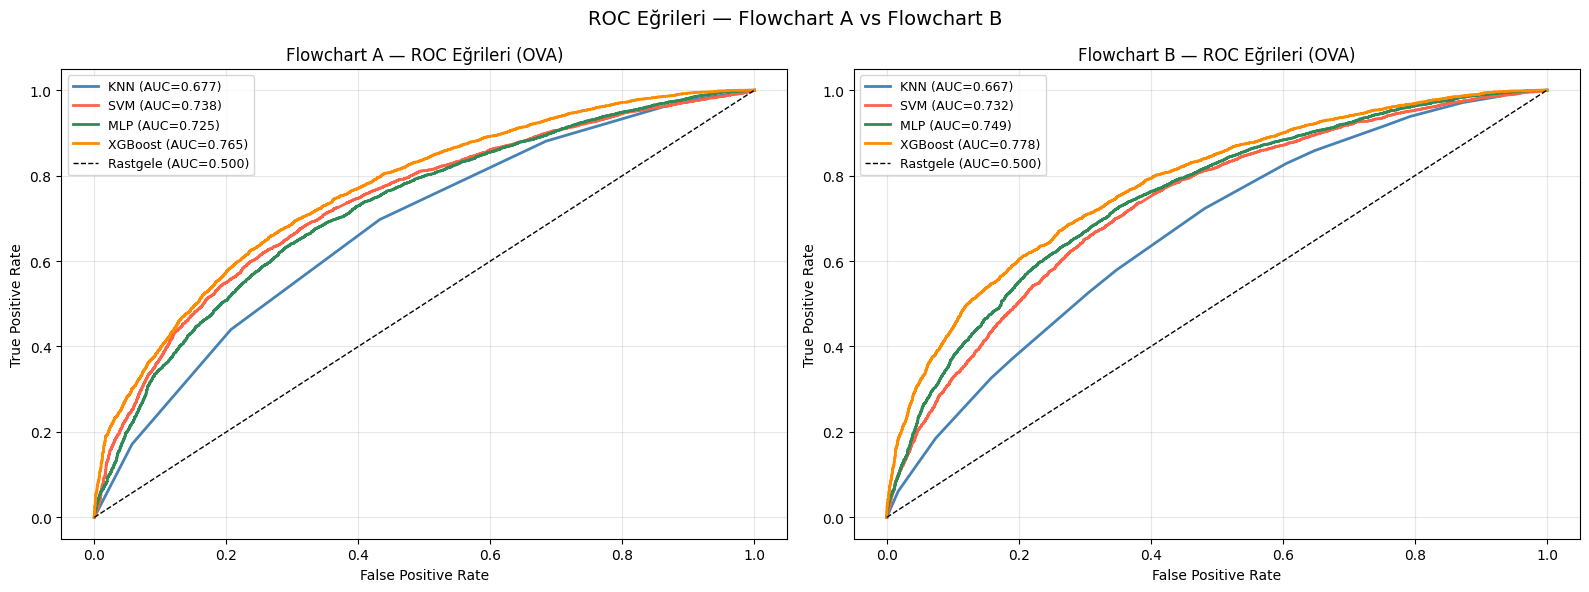

In [20]:
model_data = {
    'KNN'    : {'A': (y_test_all_knn_a, y_prob_all_knn_a),
                'B': (y_test_all_knn,   y_prob_all_knn)},
    'SVM'    : {'A': (y_test_all_svm_a, y_prob_all_svm_a),
                'B': (y_test_all_svm,   y_prob_all_svm)},
    'MLP'    : {'A': (y_test_all_mlp_a, y_prob_all_mlp_a),
                'B': (y_test_all_mlp,   y_prob_all_mlp)},
    'XGBoost': {'A': (y_test_all_xgb_a, y_prob_all_xgb_a),
                'B': (y_test_all_xgb,   y_prob_all_xgb)},
}

colors = {
    'KNN'    : 'steelblue',
    'SVM'    : 'tomato',
    'MLP'    : 'seagreen',
    'XGBoost': 'darkorange',
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, flow in zip(axes, ['A', 'B']):
    for model_name, flows in model_data.items():
        y_test_all = np.concatenate(flows[flow][0])
        y_prob_all = np.concatenate(flows[flow][1])

        fpr, tpr, _ = roc_curve(y_test_all, y_prob_all, pos_label=1)
        auc_score   = auc(fpr, tpr)

        ax.plot(fpr, tpr,
                color=colors[model_name],
                linewidth=2,
                label=f"{model_name} (AUC={auc_score:.3f})")

    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Rastgele (AUC=0.500)')
    ax.set_title(f'Flowchart {flow} — ROC Eğrileri (OVA)', fontsize=12)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('ROC Eğrileri — Flowchart A vs Flowchart B', fontsize=14)
plt.tight_layout()
plt.show()

MLP dışındaki modellerde flowchart arasında çok az fark bulunuyor. Farklar ihmal edilebilir düzeyde. Özellik seçimi stratejisinin bu modeller için belirleyici olmadığını söyleyebiliriz.

MLP'de fark daha belirgin. Flowchart B'de seçilen 15 özelliğin MLP için daha iyi bir başlangıç noktası oluşturduğu görülüyor.

### 6.3. AUC Karşılaştırma Tablosu:

Flowchart A vs Flowchart B

,Model,Flowchart,AUC
0,XGBoost,B,0.778500
1,XGBoost,A,0.764700
2,MLP,B,0.749300
3,SVM,A,0.737800
4,SVM,B,0.732000
5,MLP,A,0.724800
6,KNN,A,0.676800
7,KNN,B,0.666500


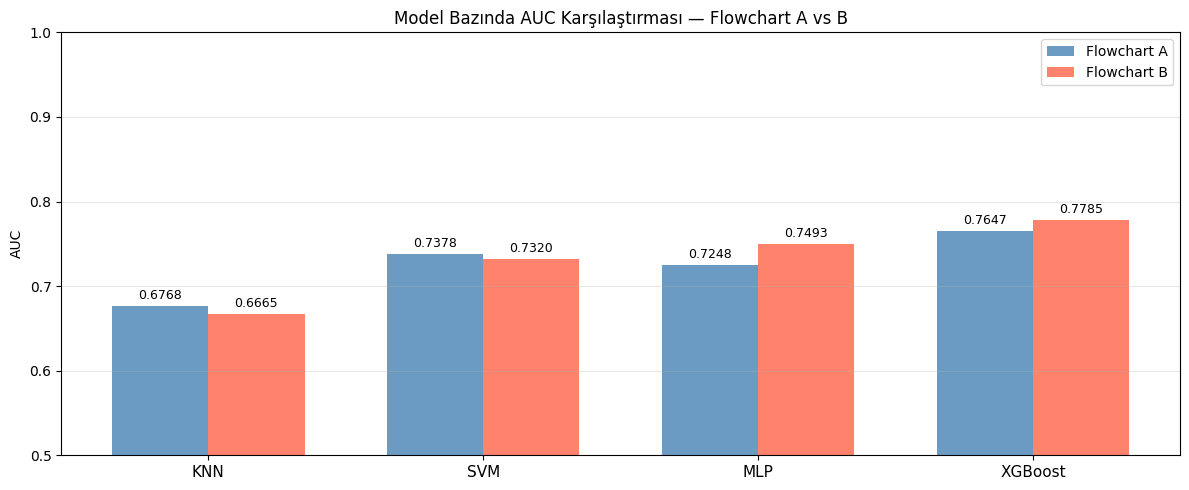

In [21]:
auc_results = []

for model_name, flows in model_data.items():
    for flow, (y_test_list, y_prob_list) in flows.items():
        y_test_all = np.concatenate(y_test_list)
        y_prob_all = np.concatenate(y_prob_list)

        auc_score = roc_auc_score(y_test_all, y_prob_all)

        auc_results.append({
            'Model'    : model_name,
            'Flowchart': flow,
            'AUC'      : round(auc_score, 4),
        })

auc_df = pd.DataFrame(auc_results).sort_values(
    ['AUC'], ascending=False
).reset_index(drop=True)

display(auc_df.style.background_gradient(
    subset=['AUC'],
    cmap='RdYlGn'
))

# Bar grafik
fig, ax = plt.subplots(figsize=(12, 5))

model_names = list(model_data.keys())
x     = np.arange(len(model_names))
width = 0.35

auc_a = [auc_df[(auc_df['Model']==m) & (auc_df['Flowchart']=='A')]['AUC'].values[0] for m in model_names]
auc_b = [auc_df[(auc_df['Model']==m) & (auc_df['Flowchart']=='B')]['AUC'].values[0] for m in model_names]

bars_a = ax.bar(x - width/2, auc_a, width, label='Flowchart A', color='steelblue', alpha=0.8)
bars_b = ax.bar(x + width/2, auc_b, width, label='Flowchart B', color='tomato',    alpha=0.8)

ax.bar_label(bars_a, fmt='%.4f', fontsize=9, padding=3)
ax.bar_label(bars_b, fmt='%.4f', fontsize=9, padding=3)

ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylabel('AUC')
ax.set_title('Model Bazında AUC Karşılaştırması — Flowchart A vs B')
ax.set_ylim(0.5, 1.0)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Sonuç:

MLP özellik seçimi ile SVM'nin iki yönteminin de üzerine çıkıyor.

KNN her iki yöntemde de en düşük performansta ve birbirine çok yakın. XGBoost ise her iki yöntemde de en yüksek performansta.


